In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"c:\Users\nabee\Downloads\customer_churn_dataset-testing-master.csv.zip")
df

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...,...
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [3]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.tail()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
64369,64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64370,64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64371,64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64372,64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1
64373,64374,52,Female,45,15,9,25,Standard,Monthly,696,22,1


In [5]:
df.shape

(64374, 12)

In [6]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [8]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

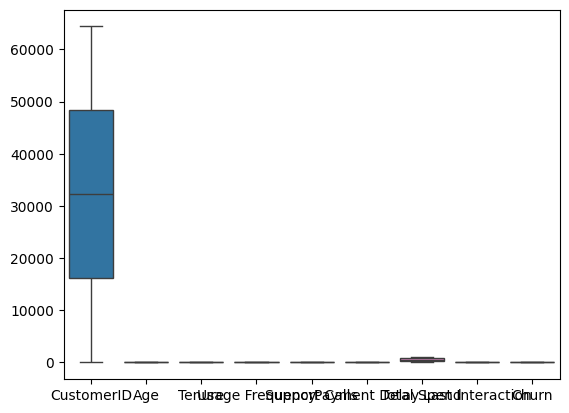

In [9]:
sns.boxplot(data=df)
plt.show()

In [10]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
le=LabelEncoder()

In [13]:
cols = ['Gender', 'Subscription Type', 'Contract Length', 'Churn']

for i in cols :
   df[i] = le.fit_transform(df[i])


print(df[cols].head())


   Gender  Subscription Type  Contract Length  Churn
0       0                  0                1      1
1       0                  2                1      0
2       1                  1                0      0
3       1                  1                2      0
4       0                  2                0      0


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler=StandardScaler()

In [34]:
x = df[['Tenure', 'Usage Frequency',
        'Support Calls', 'Payment Delay', 
         'Total Spend', 'Last Interaction']]

In [35]:
x_scale=scaler.fit_transform(x)
x_scale

array([[-0.40909964, -0.12252553, -0.44980683,  1.11453793,  0.21840769,
        -0.75232377],
       [-0.23364156,  1.46542392,  0.51359033, -0.46700013,  0.16474168,
         0.52106473],
       [-0.29212759, -0.57622537, -1.09207161,  1.34047194,  0.82790017,
         0.63682733],
       ...,
       [ 0.40970473, -0.12252553,  0.83472272,  1.45343894, -0.82041283,
         0.52106473],
       [-0.81850183,  0.44459927,  0.51359033,  0.54970291, -0.0039229 ,
        -0.28927341],
       [ 0.76062088, -0.00910057,  1.15585511,  0.88860392,  0.59406972,
         0.75258992]], shape=(64374, 6))

In [37]:
x2=pd.DataFrame(x_scale,columns=x.columns)
x2

,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction
0,-0.409100,-0.122526,-0.449807,1.114538,0.218408,-0.752324
1,-0.233642,1.465424,0.513590,-0.467000,0.164742,0.521065
2,-0.292128,-0.576225,-1.092072,1.340472,0.827900,0.636827
3,-1.344876,-0.349375,-0.128674,-0.015132,-1.184575,0.289540
4,1.520939,1.011724,1.155855,-1.709637,-0.030756,0.289540
...,...,...,...,...,...,...
64369,0.058789,-0.349375,0.192458,0.436736,1.556225,-0.173511
64370,-1.520334,-1.597050,-0.128674,0.549703,1.464226,-0.752324
64371,0.409705,-0.122526,0.834723,1.453439,-0.820413,0.521065
64372,-0.818502,0.444599,0.513590,0.549703,-0.003923,-0.289273


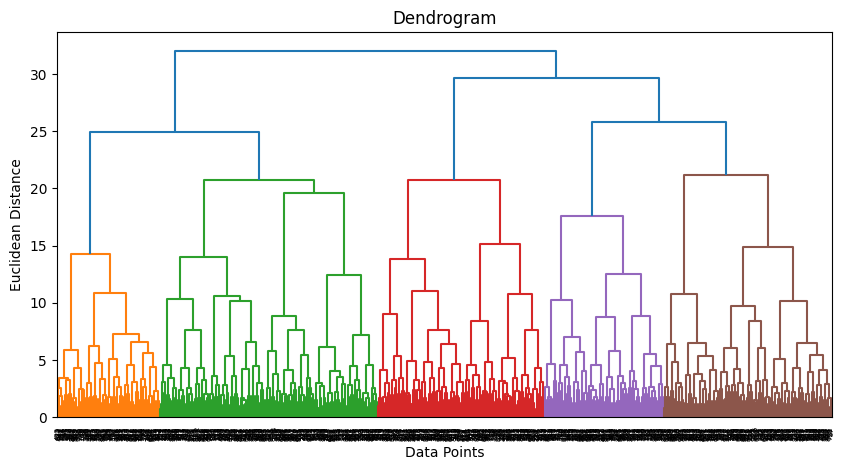

In [38]:
from scipy.cluster.hierarchy import dendrogram, linkage

x_sample = pd.DataFrame(x_scale).sample(n=1000, random_state=42)

plt.figure(figsize=(10,5))

dendrogram(linkage(x_sample, method='ward'))

plt.title('Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')

plt.show()

In [39]:
from sklearn.cluster import AgglomerativeClustering



In [40]:
hc=AgglomerativeClustering(n_clusters=4)

In [41]:

sample_df=df.sample(n=1000,random_state=42)

clusters= hc.fit_predict(x_sample)





In [42]:
sample_df['Cluster'] = clusters

In [43]:
df.head(3)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,0,25,14,4,27,0,1,598,9,1
1,2,41,0,28,28,7,13,2,1,584,20,0
2,3,47,1,27,10,2,29,1,0,757,21,0


In [48]:
df.drop('CustomerID',axis=1)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0
...,...,...,...,...,...,...,...,...,...,...,...
64369,45,0,33,12,6,21,0,2,947,14,1
64370,37,1,6,1,5,22,2,0,923,9,1
64371,25,1,39,14,8,30,1,1,327,20,1
64372,50,0,18,19,7,22,2,1,540,13,1


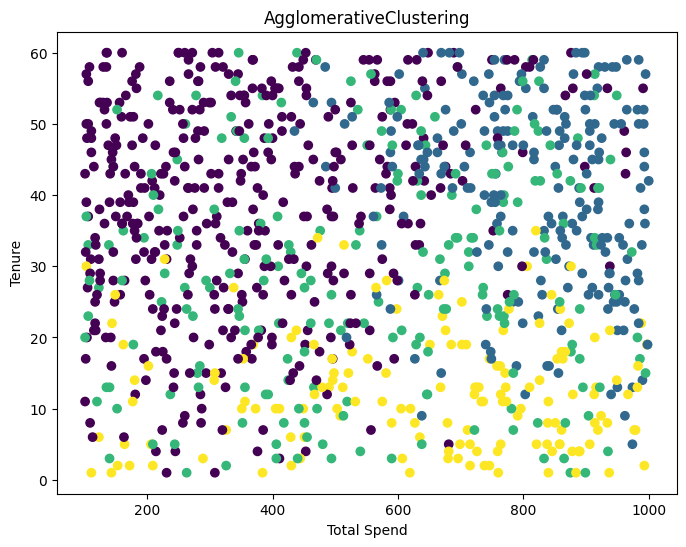

In [49]:

plt.figure(figsize=(8,6))

plt.scatter(sample_df['Total Spend'],
            sample_df['Tenure'],
            c=sample_df['Cluster'],
            cmap='viridis')


plt.xlabel('Total Spend')
plt.ylabel('Tenure')
plt.title('AgglomerativeClustering')

plt.show()

In [50]:
from sklearn.metrics import silhouette_score

In [51]:
score= silhouette_score(x_sample,clusters)

print("silhouette_score", score)

silhouette_score 0.07261095326292093
